In [2]:
# Importing the required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load dataset
df = pd.read_csv(r"C:\Users\asaad\Desktop\Heart21F22072.csv") 

In [4]:
# Display basic info and first rows
print(df.info())

# Show first 5 rows of the dataframe
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB
None
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0

In [5]:
# Calculate correlation matrix
corr_matrix = df.corr()

In [6]:
# Show correlation of each feature with the target 'condition'
print(corr_matrix['condition'].sort_values(ascending=False))

condition    1.000000
thal         0.520516
ca           0.463189
oldpeak      0.424052
exang        0.421355
cp           0.408945
slope        0.333049
sex          0.278467
age          0.227075
restecg      0.166343
trestbps     0.153490
chol         0.080285
fbs          0.003167
thalach     -0.423817
Name: condition, dtype: float64


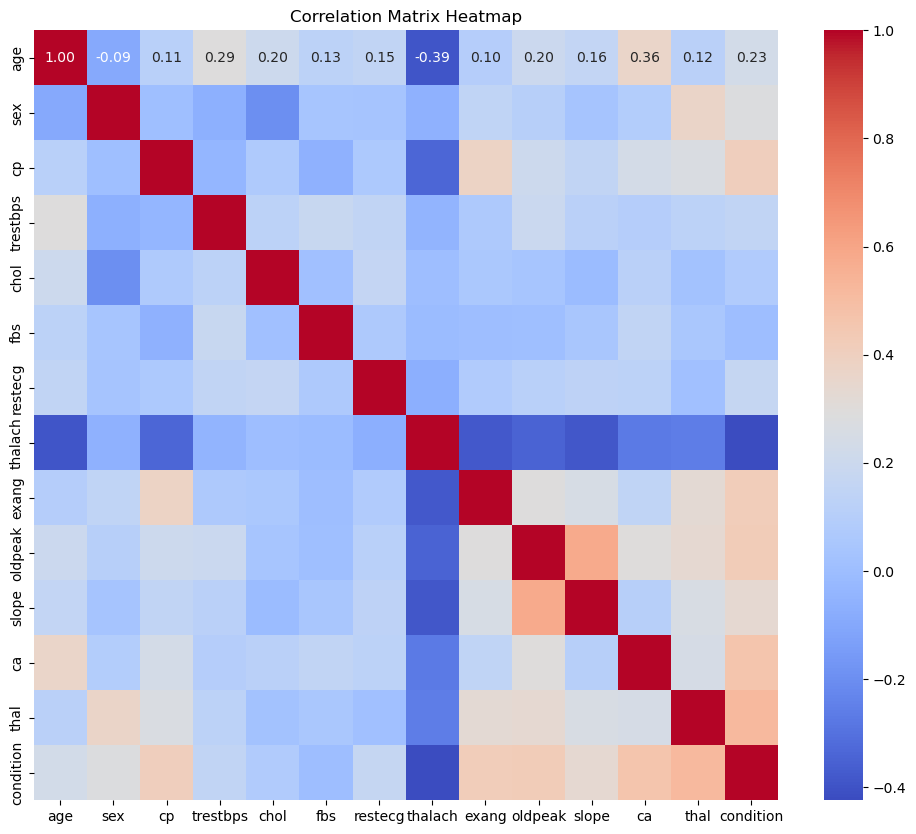

In [7]:
# Plotting heatmap of correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

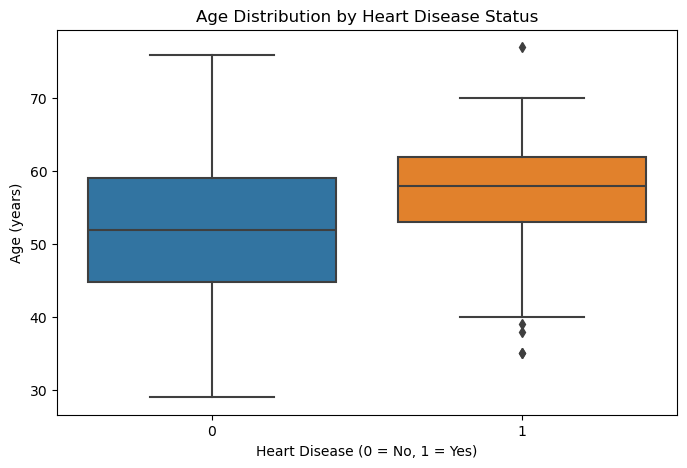

In [8]:
# Boxplot: Age distribution by heart disease presence
plt.figure(figsize=(8,5))
sns.boxplot(x='condition', y='age', data=df)
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Age (years)')
plt.show()

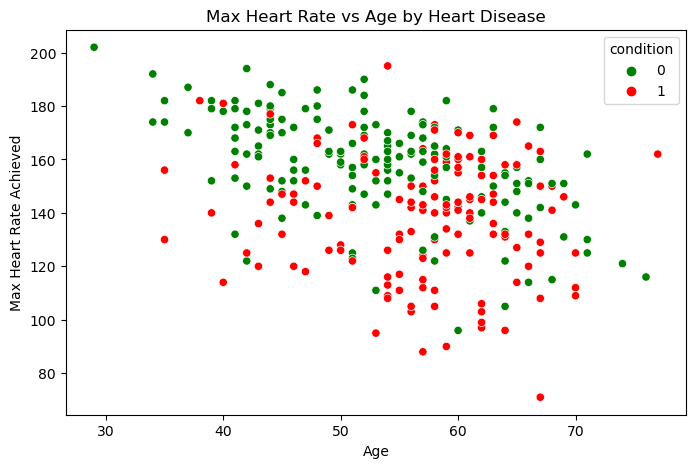

In [9]:
# Scatter plot: Max Heart Rate vs Age, colored by heart disease condition
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='thalach', hue='condition', data=df, palette=['green', 'red'])
plt.title('Max Heart Rate vs Age by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate Achieved')
plt.show()

In [10]:
#Load Data and Replace Missing Values
import pandas as pd
import numpy as np

# Loading the heart disease (Heart21F22072) dataset
df = pd.read_csv(r"C:\Users\asaad\Desktop\Heart21F22072.csv") 

print("Initial data sample:")
print(df.head())

# Replacing the '?' (to check missing or unknown data) with NaN (Not a Number) and inplace updates the dataframe directly without making a new one
df.replace('?', np.nan, inplace=True)

print("\nMissing values count after replacement:")
print(df.isnull().sum())


Initial data sample:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  

Missing values count after replacement:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64


In [11]:
#Data Type Conversion
# Converting the relevant columns (features) to categorical type
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Converting the numerical columns from text to numbers to make calculations possible
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'condition']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nData types after conversion:")
print(df.dtypes)



Data types after conversion:
age             int64
sex          category
cp           category
trestbps        int64
chol            int64
fbs          category
restecg      category
thalach         int64
exang        category
oldpeak       float64
slope        category
ca           category
thal         category
condition       int64
dtype: object


In [12]:
#Handling Missing Values
# Converting 'ca' and 'thal' to numerical numbers and filling in the missing values with mode
for col in ['ca', 'thal']:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    
    print(f"Missing values in '{col}' after imputation: {df[col].isnull().sum()}")


Missing values in 'ca' after imputation: 0
Missing values in 'thal' after imputation: 0


In [13]:
# Encoding Categorical Variables
# Applying the One-Hot Encoding to change categories into numbers for the Heart21F22072 dataset.
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nData sample after encoding:")
print(df.head())



Data sample after encoding:
   age  trestbps  chol  thalach  oldpeak  condition  sex_1   cp_1   cp_2  \
0   69       160   234      131      0.1          0   True  False  False   
1   69       140   239      151      1.8          0  False  False  False   
2   66       150   226      114      2.6          0  False  False  False   
3   65       138   282      174      1.4          1   True  False  False   
4   64       110   211      144      1.8          0   True  False  False   

    cp_3  ...  restecg_1  restecg_2  exang_1  slope_1  slope_2   ca_1   ca_2  \
0  False  ...      False       True    False     True    False   True  False   
1  False  ...      False      False    False    False    False  False   True   
2  False  ...      False      False    False    False     True  False  False   
3  False  ...      False       True    False     True    False   True  False   
4  False  ...      False       True     True     True    False  False  False   

    ca_3  thal_1  thal_2  
0  Fal

In [14]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

# Columns to scale (continuous numeric features)
scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Creating a scaler object
scaler = StandardScaler()

# Apply scaling: mean=0, std=1 for each selected column
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("\nData sample after scaling:")
print(df.head())



Data sample after scaling:
        age  trestbps      chol   thalach   oldpeak  condition  sex_1   cp_1  \
0  1.600302  1.596266 -0.257179 -0.812095 -0.820813          0   True  False   
1  1.600302  0.468418 -0.160859  0.061157  0.639470          0  False  False   
2  1.268242  1.032342 -0.411292 -1.554358  1.326662          0  False  False   
3  1.157555  0.355633  0.667499  1.065396  0.295874          1   True  False   
4  1.046868 -1.223355 -0.700254 -0.244481  0.639470          0   True  False   

    cp_2   cp_3  ...  restecg_1  restecg_2  exang_1  slope_1  slope_2   ca_1  \
0  False  False  ...      False       True    False     True    False   True   
1  False  False  ...      False      False    False    False    False  False   
2  False  False  ...      False      False    False    False     True  False   
3  False  False  ...      False       True    False     True    False   True   
4  False  False  ...      False       True     True     True    False  False   

    ca_2  

In [15]:
# Outlier Detection and Removal (IQR Method)
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for scaled columns
Q1 = df[scale_cols].quantile(0.25)
Q3 = df[scale_cols].quantile(0.75)

# Interquartile range (IQR)
IQR = Q3 - Q1

# Counting the rows before removing outliers
before_rows = df.shape[0]

# Filter rows to remove outliers:
# Keep rows where values are NOT below Q1 - 1.5*IQR or above Q3 + 1.5*IQR in any scaled column
df = df[~((df[scale_cols] < (Q1 - 1.5 * IQR)) | (df[scale_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Count rows after removing outliers
after_rows = df.shape[0]

print(f"\nRows before removing outliers: {before_rows}")
print(f"Rows after removing outliers: {after_rows}")



Rows before removing outliers: 297
Rows after removing outliers: 277


In [16]:
#Train-Test Split
from sklearn.model_selection import train_test_split

# Separate features (X) and condition variable (y)
X = df.drop('condition', axis=1)
y = df['condition']

# Split dataset into training (80%) and testing (20%) sets
# stratify=y to keep class distribution balanced in splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")



Train samples: 221
Test samples: 56


In [17]:
# Importing the Decision Tree Classifier from scikit-learn
from sklearn.tree import DecisionTreeClassifier

# Importing the tools required to evaluate the model performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Creating a Decision Tree model using 'entropy' as the splitting rule and training the model by using the training data (features and labels)
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_model.fit(X_train, y_train)

# Using the trained model to predict the labels for the test data
y_pred_dt = dt_model.predict(X_test)


print("Decision Tree Classifier Results")

# Show a confusion matrix to compare predicted vs actual test labels
print(confusion_matrix(y_test, y_pred_dt))

# Show the precision, recall, F1-score, and support for each class
print(classification_report(y_test, y_pred_dt))

# Show the overall accuracy of the model
print("Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Classifier Results
[[26  5]
 [ 8 17]]
              precision    recall  f1-score   support

           0       0.76      0.84      0.80        31
           1       0.77      0.68      0.72        25

    accuracy                           0.77        56
   macro avg       0.77      0.76      0.76        56
weighted avg       0.77      0.77      0.77        56

Accuracy: 0.7678571428571429


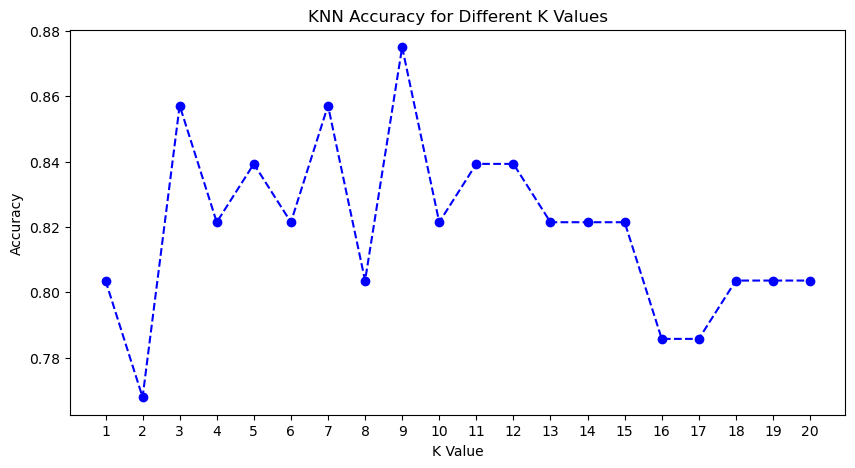

Best K value is: 9


In [18]:
# Importing the (KNN) K-Nearest Neighbors classifier and plotting library from python
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Creating a list of K values from 1 to 20
k_range = range(1, 21)

# Creating an empty list to store the accuracy scores
accuracies = []

# For each K value, training and testing the KNN model will be done
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)  # KNN model creation with current K
    knn.fit(X_train, y_train)                  # Train model on training data
    y_pred_k = knn.predict(X_test)             # Predicting the test data labels
    acc = accuracy_score(y_test, y_pred_k)     # Calculating accuracy of predictions
    accuracies.append(acc)                     # Saving accuracy score

# Creating a graph to show the accuracy for each K values
plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='blue')
plt.xlabel('K Value')          # Labeling as x-axis
plt.ylabel('Accuracy')         # Labeling as y-axis
plt.title('KNN Accuracy for Different K Values')  # Add title as "KNN Accuracy for Different K Values"
plt.xticks(k_range)            # Showing all the K values on x-axis
plt.show()                     # Displaying the plot

# Finding and printing the best K value that gives the highest accuracy
best_k = k_range[accuracies.index(max(accuracies))]
print("Best K value is:", best_k)


In [19]:
# Training the KNN model again by using the best K value found earlier
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)  # Training the model with training data

# Using the trained model to predict labels for the test data
y_pred_knn = knn_model.predict(X_test)

# Printing the results to evaluate the model's performance
print(" KNN Classifier (k =", best_k, ") ")
print(confusion_matrix(y_test, y_pred_knn))       # Show the confusion matrix
print(classification_report(y_test, y_pred_knn))  # Show a detailed classification report
print("Accuracy:", accuracy_score(y_test, y_pred_knn))  # Show the accuracy score


 KNN Classifier (k = 9 ) 
[[29  2]
 [ 5 20]]
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        31
           1       0.91      0.80      0.85        25

    accuracy                           0.88        56
   macro avg       0.88      0.87      0.87        56
weighted avg       0.88      0.88      0.87        56

Accuracy: 0.875


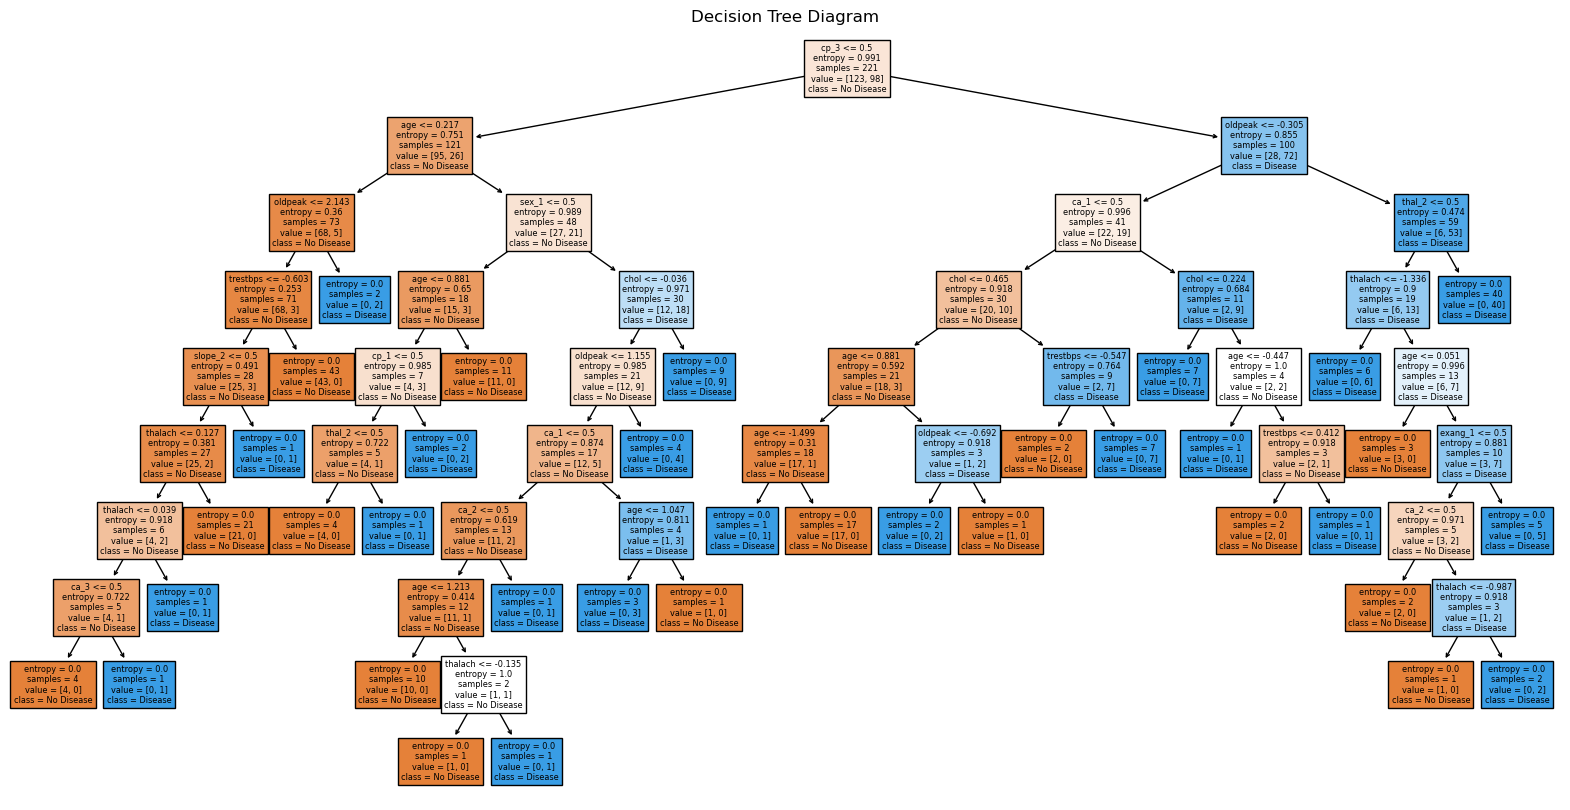

In [20]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Creating a large graph for the decision tree
plt.figure(figsize=(20,10))  # Setting the size of the plot

# Plotting the tree structure of the trained Decision Tree model
plot_tree(
    dt_model,                    # The trained decision tree model
    feature_names=X.columns,     # Column names used in the dataset
    class_names=['No Disease', 'Disease'],  # Labels for the target variable
    filled=True                  # Filling in the colors to indicate class distribution
)

# Adding a title to the plot
plt.title("Decision Tree Diagram")

# Show the plot
plt.show()
